In [1]:
from __future__ import absolute_import

import sys
if '../' not in sys.path:
  sys.path.append('../')

import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt

%matplotlib inline

Check that our tanh is correct:
False
[0.00182044 0.00195287 0.0020949  0.00224725 0.00241065 0.00258589
 0.00277384 0.00297541 0.00319158 0.00342341 0.00367201 0.00393859
 0.00422444 0.00453094 0.00485957 0.00521191 0.00558965 0.00599461
 0.00642871 0.00689403 0.00739278 0.00792732 0.00850017 0.00911404
 0.0097718  0.01047652 0.01123148 0.01204018 0.01290634 0.01383392
 0.01482716 0.01589054 0.01702884 0.01824714 0.01955084 0.02094566
 0.02243766 0.02403327 0.02573928 0.02756289 0.02951167 0.03159361
 0.03381714 0.0361911  0.03872477 0.04142787 0.04431057 0.04738346
 0.05065756 0.05414432 0.05785556 0.06180348 0.06600059 0.07045971
 0.07519385 0.08021621 0.08554005 0.09117859 0.09714496 0.10345197
 0.11011204 0.11713701 0.12453791 0.13232481 0.14050652 0.14909037
 0.15808191 0.1674846  0.17729949 0.1875249  0.198156   0.20918451
 0.22059827 0.23238091 0.24451146 0.25696405 0.26970757 0.2827054
 0.29591527 0.30928906 0.32277278 0.33630664 0.3498252  0.3632577
 0.37652842 0.38955735 0.4

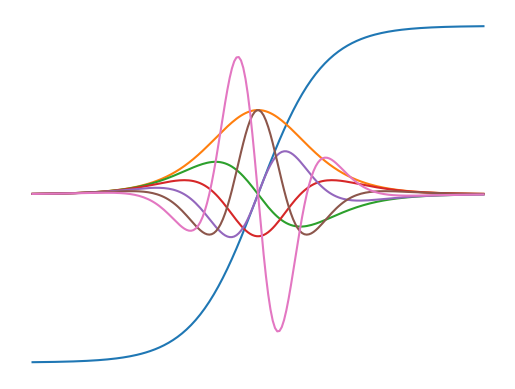

In [ ]:
# We could use np.tanh, but let's write our own as an example.

def tanh(x):
    return (1.0 - np.exp(-x))  / (1.0 + np.exp(-x))

def gtanh(x):
    return 1.0 / np.cosh(x)**2

def graphgtanh(x):
    g = np.ones_like(x)
    g1 = g / (1.0+np.exp(-x))
    g2 = -g * (1.0-np.exp(-x)) / (1.0+np.exp(-x))**2
    g1 = -g1
    g2 = g2
    g1 = np.exp(-x) * g1
    g2 = np.exp(-x) * g2
    g1 = -g1
    g2 = -g2
    return g1 + g2
    # return np.exp(-x) * g / (1.0+np.exp(-x)) + np.exp(-x) * g * (1.0-np.exp(-x)) / (1+np.exp(-x))**2

x = np.linspace(-7, 7, 200)

print("Check that our tanh is correct:")
print(np.allclose(grad(tanh)(x), gtanh(x)))
print(grad(tanh)(x))
print(graphgtanh(x))
print(grad(tanh)(x) == graphgtanh(x))


plt.plot(x, tanh(x),
         x, grad(tanh)(x),                                # first  derivative
         x, grad(grad(tanh))(x),                          # second derivative
         x, grad(grad(grad(tanh)))(x),                    # third  derivative
         x, grad(grad(grad(grad(tanh))))(x),              # fourth derivative
         x, grad(grad(grad(grad(grad(tanh)))))(x),        # fifth  derivative
         x, grad(grad(grad(grad(grad(grad(tanh))))))(x),  # sixth  derivative
         )

plt.axis('off')
plt.savefig("tanh.png")
plt.show()

In [5]:
# How does Autograd deal with broadcasting?

from autograd.numpy.numpy_vjps import unbroadcast

x = 2.0

# Let f(x) = x + [1, 1, 1].
#
# If x[], then it is numpy first prepends as many length-1 dims as necessary (in this case, 1) to get
# x[1], then copies along those length-1 dims to match [1, 1, 1] (in this case, 3x).
#
# We can look at f(x) as f(x_1=x, x_2=x, x_3=x). Then the total derivative of f() wrt x is,
# df/dx = \sum_{i} (df/dx_i) (dx_i/dx)
#       = \sum_{i} 1 * 1
#       = 3 = number of times x was copied.

def f(x):
    return x + np.ones((3,))

x = 2.0
y = f(x)
g = np.ones(np.shape(y))
print(unbroadcast(x, g))

# Any time numpy needs to broadcast, it clones the broadcasted value along leading dimensions.
# During backpropagation, we sum over these dimensions as total derivative requires.
print('')

x = np.arange(2).reshape((2, 1))
y = f(x)
g = np.ones(np.shape(y))
print(unbroadcast(x, g))

3.0

[[3.]
 [3.]]


In [6]:
# What does Autograd do when a function has non-differentiable functions?
#
# It assumes their derivative is zero wrt their inputs.

def foo(x):
    return np.floor(x) + x

grad(foo)(1.5)

array(1.)